# Scratch baselines without SAM — CustomCNN, ResNet18, ViT
- Same preprocessing, cosine+warmup schedule, early stopping on AUROC.
- Final metrics shown at 0.5 and at a *recall‑first* operating point (screening).


In [14]:
# Make sure Python can import the package by name:
import sys
from pathlib import Path

# If the notebook is inside notebooks/, add the parent (project root) to sys.path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("sys.path[0] =", sys.path[0])

# Now import from the package by name (ABSOLUTE import, no leading dot)
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project


device(type='mps')

In [15]:
DATASET_DIR = Path("../Data/chest_xray")

data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=2,
    val_ratio=0.20,
    balance_sampler=True,
    compute_norm_stats=False,
    gray_to_rgb=True
)

scratch_cfg = TrainCfg(
    epochs=100, patience=15, monitor="va_auroc",
    base_lr=3e-4, weight_decay=0.3,
    clip_grad_norm=1.0, use_amp=False,
    use_sam=False, sam_rho=0.2,
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    target_recall=0.95,
    llrd=False, head_lr_mult=10.0
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, device=DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Class weights for imbalance
arr = np.array(info["train_counts"], dtype=float)
w = arr.sum() / (len(arr) * (arr + 1e-9))
class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)
# OPTIONAL (avoid double-correction): uncomment next line when balance_sampler=True
class_weights = None


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079, 3106]


In [ ]:
cfg = scratch_cfg

cnn = build_custom_cnn(num_classes=2, width=32, dropout=0.0)
t0 = time.time()
cnn_tr, cnn_hist, cnn_time = train_model(
    cnn, train_loader, val_loader, DEVICE, arch="custom_cnn",
    epochs=cfg.epochs, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.02,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="CustomCNN-scratch"
)
cnn_time = time.time() - t0

plot_curve(cnn_hist['tr_loss'], cnn_hist['va_loss'], "CustomCNN — Loss")
plot_two_series(cnn_hist['va_acc'], "Val Acc", cnn_hist['va_f1'], "Val F1", "CustomCNN — Val")

va = evaluate(cnn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(cnn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[CustomCNN @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[CustomCNN @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("CustomCNN (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("CustomCNN (scratch)", cnn_tr, sum_05, sum_reca, threshold=thr, time_sec=cnn_time)


[CustomCNN-scratch] epoch 01/100  tr_loss=0.4635  val_loss=2.9678  val_acc=0.2627  val_f1=0.0128  val_auroc=0.8578  (no_improve=0)
[CustomCNN-scratch] epoch 02/100  tr_loss=0.4528  val_loss=0.3328  val_acc=0.8567  val_f1=0.8960  val_auroc=0.9379  (no_improve=0)
[CustomCNN-scratch] epoch 03/100  tr_loss=0.4466  val_loss=0.3181  val_acc=0.8424  val_f1=0.9015  val_auroc=0.9404  (no_improve=0)
[CustomCNN-scratch] epoch 04/100  tr_loss=0.3981  val_loss=0.3195  val_acc=0.8730  val_f1=0.9082  val_auroc=0.9547  (no_improve=0)
[CustomCNN-scratch] epoch 05/100  tr_loss=0.3832  val_loss=0.5692  val_acc=0.8185  val_f1=0.8619  val_auroc=0.9510  (no_improve=1)
[CustomCNN-scratch] epoch 06/100  tr_loss=0.3920  val_loss=0.2709  val_acc=0.8816  val_f1=0.9244  val_auroc=0.9572  (no_improve=0)
[CustomCNN-scratch] epoch 07/100  tr_loss=0.3789  val_loss=0.2751  val_acc=0.8940  val_f1=0.9315  val_auroc=0.9609  (no_improve=0)
[CustomCNN-scratch] epoch 08/100  tr_loss=0.3698  val_loss=0.2689  val_acc=0.8873  

[ResNet18-scratch] epoch 01/90  tr_loss=0.4123  val_loss=2.0951  val_acc=0.3419  val_f1=0.2035  val_auroc=0.9012  (no_improve=0)
[ResNet18-scratch] epoch 02/90  tr_loss=0.5094  val_loss=0.3341  val_acc=0.8309  val_f1=0.8720  val_auroc=0.9781  (no_improve=0)
[ResNet18-scratch] epoch 03/90  tr_loss=0.4239  val_loss=2.5004  val_acc=0.4804  val_f1=0.4614  val_auroc=0.9305  (no_improve=1)
[ResNet18-scratch] epoch 04/90  tr_loss=0.3448  val_loss=0.3867  val_acc=0.7459  val_f1=0.7957  val_auroc=0.9418  (no_improve=2)
[ResNet18-scratch] epoch 05/90  tr_loss=0.3309  val_loss=0.3004  val_acc=0.8309  val_f1=0.8728  val_auroc=0.9649  (no_improve=3)
[ResNet18-scratch] epoch 06/90  tr_loss=0.3222  val_loss=0.2060  val_acc=0.8959  val_f1=0.9259  val_auroc=0.9774  (no_improve=4)
[ResNet18-scratch] epoch 07/90  tr_loss=0.3096  val_loss=0.3196  val_acc=0.8195  val_f1=0.8625  val_auroc=0.9743  (no_improve=5)
[ResNet18-scratch] epoch 08/90  tr_loss=0.2724  val_loss=0.2456  val_acc=0.8863  val_f1=0.9189  v

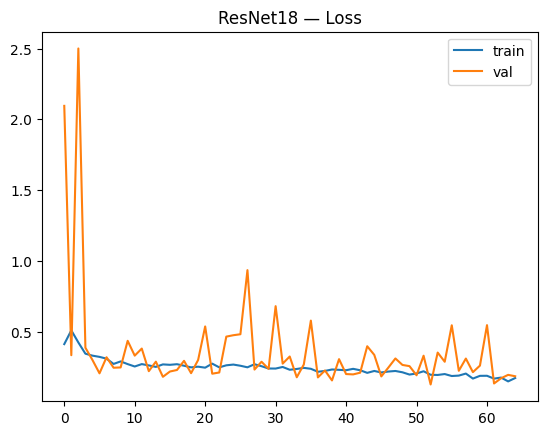

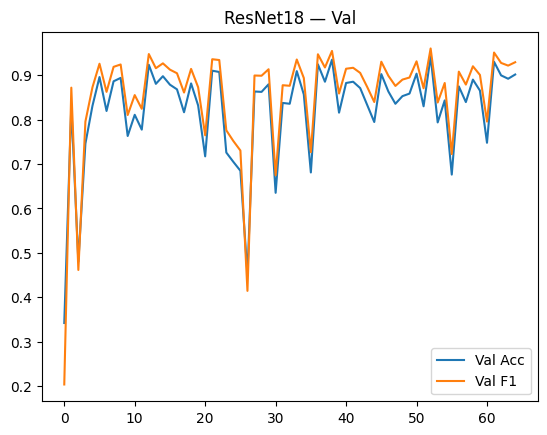

[ResNet18-scratch @0.5] {'acc': 0.867, 'precision': 0.9324, 'recall': 0.8487, 'f1': 0.8886, 'auroc': 0.9511, 'thr': 0.5}
[ResNet18-scratch @Rec] {'acc': 0.883, 'precision': 0.8499, 'recall': 0.9872, 'f1': 0.9134, 'auroc': 0.9511, 'thr': 0.076}


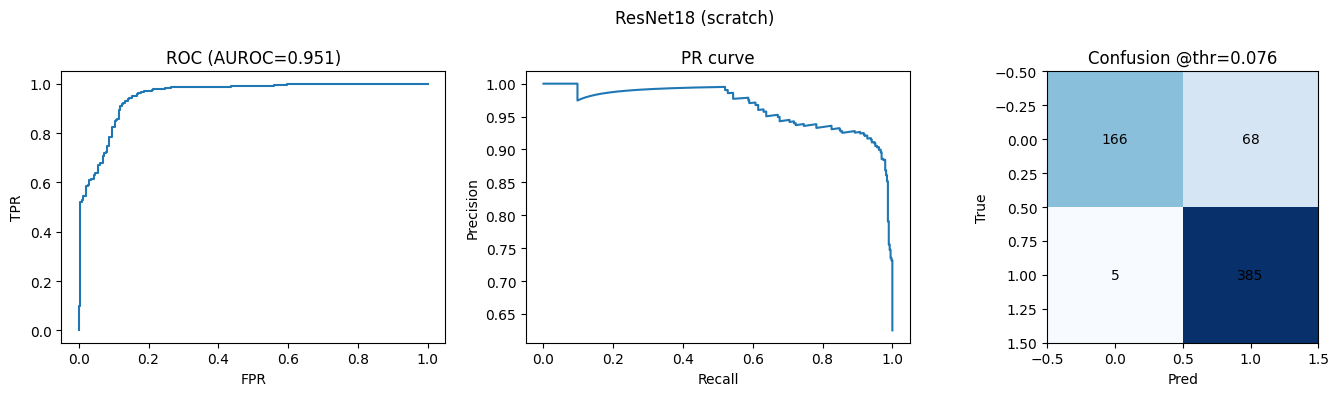

{'summary@0.5': {'acc': 0.8669871794871795,
  'precision': 0.9323943661971831,
  'recall': 0.8487179487179487,
  'f1': 0.8885906040268456,
  'auroc': 0.9510628972167434,
  'thr': 0.5},
 'summary@recall': {'acc': 0.8830128205128205,
  'precision': 0.8498896247240618,
  'recall': 0.9871794871794872,
  'f1': 0.9134045077105575,
  'auroc': 0.9510628972167434,
  'thr': 0.076},
 'threshold': 0.076,
 'time_sec': 4019.1577620506287,
 'params': 11177538}

In [ ]:
rn = build_resnet18(in_chans=3, num_classes=2, pretrained=False, conv_stem=False)
t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=90, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.05,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-scratch"
)
rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-scratch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-scratch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (scratch)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-scratch] epoch 01/120  tr_loss=0.5151  val_loss=0.3882  val_acc=0.8806  val_f1=0.9210  val_auroc=0.9377  (no_improve=0)
[ViT-scratch] epoch 02/120  tr_loss=0.4806  val_loss=0.6453  val_acc=0.5721  val_f1=0.5964  val_auroc=0.9499  (no_improve=0)
[ViT-scratch] epoch 03/120  tr_loss=0.4322  val_loss=0.5448  val_acc=0.6839  val_f1=0.7294  val_auroc=0.9548  (no_improve=0)
[ViT-scratch] epoch 04/120  tr_loss=0.4106  val_loss=0.3891  val_acc=0.7622  val_f1=0.8109  val_auroc=0.9429  (no_improve=1)
[ViT-scratch] epoch 05/120  tr_loss=0.4057  val_loss=0.2977  val_acc=0.8701  val_f1=0.9072  val_auroc=0.9535  (no_improve=2)
[ViT-scratch] epoch 06/120  tr_loss=0.3936  val_loss=0.4430  val_acc=0.6915  val_f1=0.7389  val_auroc=0.9574  (no_improve=0)
[ViT-scratch] epoch 07/120  tr_loss=0.3974  val_loss=0.4715  val_acc=0.7030  val_f1=0.7518  val_auroc=0.9416  (no_improve=1)
[ViT-scratch] epoch 08/120  tr_loss=0.3985  val_loss=0.4541  val_acc=0.7192  val_f1=0.7667  val_auroc=0.9698  (no_improve=0)


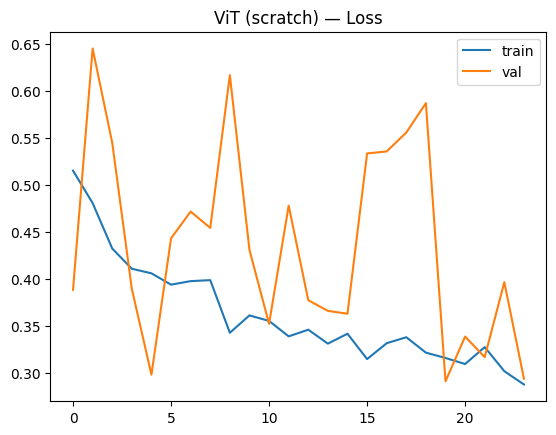

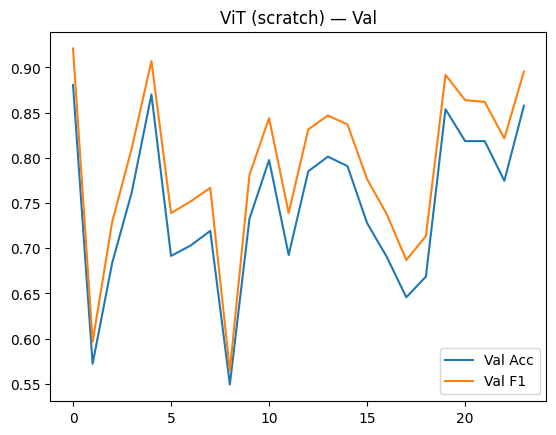

[ViT-scratch @0.5] {'acc': 0.6186, 'precision': 0.981, 'recall': 0.3974, 'f1': 0.5657, 'auroc': 0.9063, 'thr': 0.5}
[ViT-scratch @Rec] {'acc': 0.7869, 'precision': 0.7565, 'recall': 0.9718, 'f1': 0.8507, 'auroc': 0.9063, 'thr': 0.0475}


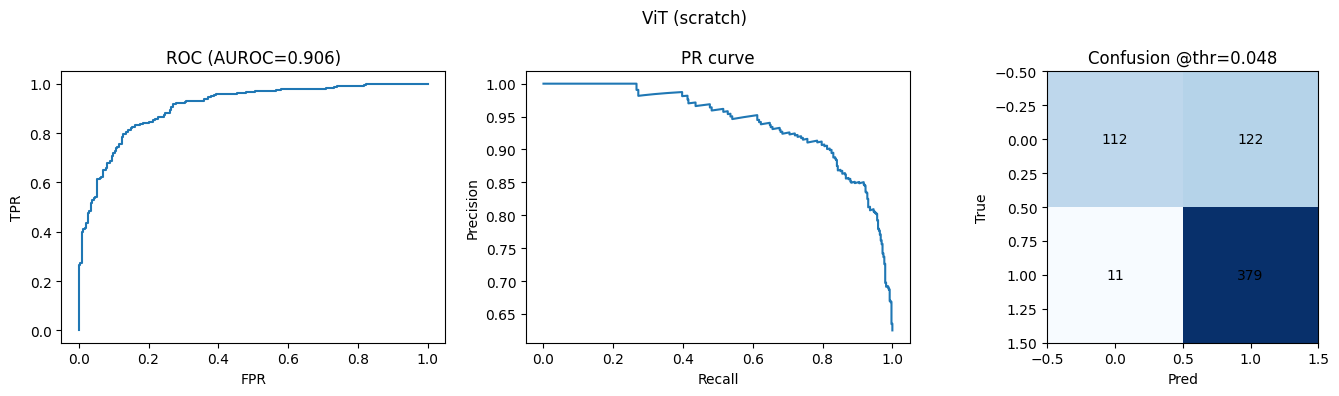

{'summary@0.5': {'acc': 0.6185897435897436,
  'precision': 0.9810126582278481,
  'recall': 0.3974358974358974,
  'f1': 0.5656934306569343,
  'auroc': 0.9063225947841332,
  'thr': 0.5},
 'summary@recall': {'acc': 0.7868589743589743,
  'precision': 0.7564870259481038,
  'recall': 0.9717948717948718,
  'f1': 0.8507295173961841,
  'auroc': 0.9063225947841332,
  'thr': 0.0475},
 'threshold': 0.0475,
 'time_sec': 2530.771444797516,
 'params': 21666434}

In [ ]:
vit = build_vit_scratch(img_size=224, in_chans=3, num_classes=2,
                        embed_dim=384, depth=12, heads=6, patch=16, mlp_ratio=4.0, drop=0.1)
t0 = time.time()
vit_tr, vit_hist, vit_time = train_model(
    vit, train_loader, val_loader, DEVICE, arch="vit",
    epochs=120, base_lr=3e-4, weight_decay=0.3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.2,
    use_cosine=True, warmup_epochs=5, min_lr_mult=0.01,
    monitor="va_auroc", patience=15, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=10.0, use_amp=False,
    tag="ViT-scratch"
)
vit_time = time.time() - t0

plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT (scratch) — Loss")
plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT (scratch) — Val")

va = evaluate(vit_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], scratch_cfg.target_recall)
te = evaluate(vit_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ViT-scratch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ViT-scratch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ViT (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ViT (scratch)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [ ]:
import pandas as pd
from src import result_registry as RR

rows=[]
for name, d in RR.items():
    s = d.get("summary@recall", d.get("summary@0.5"))
    if not s: continue
    thr = d.get("threshold", s.get("thr", 0.5))
    rows.append({
        "Model": name,
        "Params (M)": round(d.get("params", 0)/1e6, 2) if d.get("params") else None,
        "Time (min)": round(d.get("time_sec", 0)/60, 2) if d.get("time_sec") else None,
        "Acc": round(s["acc"],4), "Prec": round(s["precision"],4),
        "Recall": round(s["recall"],4), "F1": round(s["f1"],4),
        "AUROC": round(s.get("auroc", float('nan')),4), "Thr": round(thr,3)
    })
df = pd.DataFrame(rows).sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
display(df); print(df.to_string(index=False))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,ResNet18 (scratch),11.18,66.99,0.8830,0.8499,0.9872,0.9134,0.9511,0.076
1,ViT (scratch),21.67,42.18,0.7869,0.7565,0.9718,0.8507,0.9063,0.048
2,CustomCNN (scratch),0.48,31.70,0.7676,0.7379,0.9744,0.8398,0.9092,0.144


              Model  Params (M)  Time (min)    Acc   Prec  Recall     F1  AUROC   Thr
 ResNet18 (scratch)       11.18       66.99 0.8830 0.8499  0.9872 0.9134 0.9511 0.076
      ViT (scratch)       21.67       42.18 0.7869 0.7565  0.9718 0.8507 0.9063 0.048
CustomCNN (scratch)        0.48       31.70 0.7676 0.7379  0.9744 0.8398 0.9092 0.144
